<a href="https://colab.research.google.com/github/Khanbir/Data_analitycs/blob/main/DZ_16_2_%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%94_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv ('/content/drive/MyDrive/credit_risk_dataset.csv')

# Вивести розмір датасету
print("Розмір датасету:", df.shape)

# Показати перші 5 рядків
print("\nПерші 5 рядків:")
display(df.head())

# Вивести загальну інформацію про дані
print("\nЗагальна інформація:")
display(df.info())

# Перевірити розподіл цільової змінної
print("\nРозподіл цільової змінної (loan_status):")
loan_status_distribution = df['loan_status'].value_counts(normalize=True) * 100
print(loan_status_distribution)

# Висновок про збалансованість
if loan_status_distribution[0] > 60 or loan_status_distribution[1] > 60:
    print("\nВисновок: Задача незбалансованої класифікації.")
else:
    print("\nВисновок: Задача збалансованої класифікації.")

Розмір датасету: (32581, 12)

Перші 5 рядків:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Загальна інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None


Розподіл цільової змінної (loan_status):
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Висновок: Задача незбалансованої класифікації.



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


Відсоток пропущених значень:
Series([], dtype: float64)

Перевірка на пропущені значення після заповнення:
0

Опис числових змінних:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



Обробка викидів в person_income:
Кількість викидів у person_income: 1484
Розмір датасету після видалення викидів: (31097, 12)

Аналіз категоріальних змінних:

Розподіл значень в колонці 'person_home_ownership':
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Розподіл 'person_home_ownership' відносно loan_status:


loan_status,0,1
person_home_ownership,,
MORTGAGE,11754,1690
OTHER,74,33
OWN,2391,193
RENT,11254,5192



Розподіл значень в колонці 'loan_intent':
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Розподіл 'loan_intent' відносно loan_status:


...


Розподіл значень в колонці 'loan_grade':
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Розподіл 'loan_grade' відносно loan_status:


loan_status,0,1
loan_grade,,
A,9704,1073
B,8750,1701
C,5119,1339
D,1485,2141
E,343,621
F,71,170
G,1,63



Розподіл значень в колонці 'cb_person_default_on_file':
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

Розподіл 'cb_person_default_on_file' відносно loan_status:


loan_status,0,1
cb_person_default_on_file,,
N,21900,4936
Y,3573,2172



Візуалізація взаємозв'язків з loan_status:


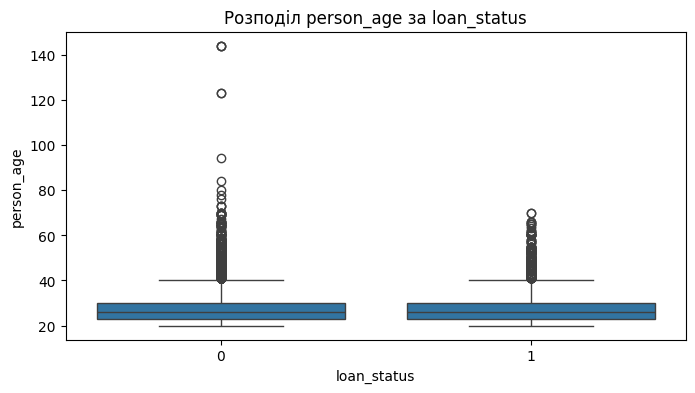

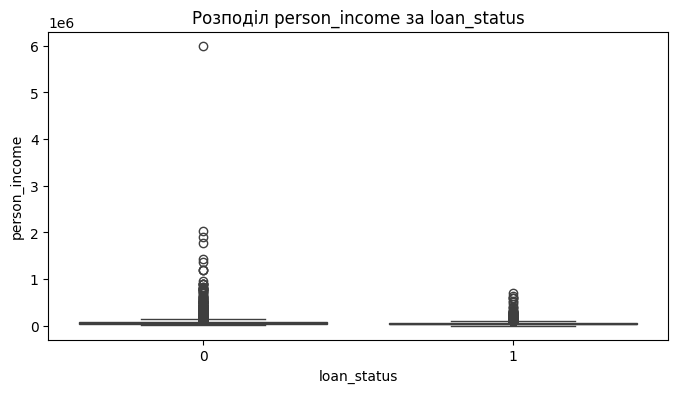

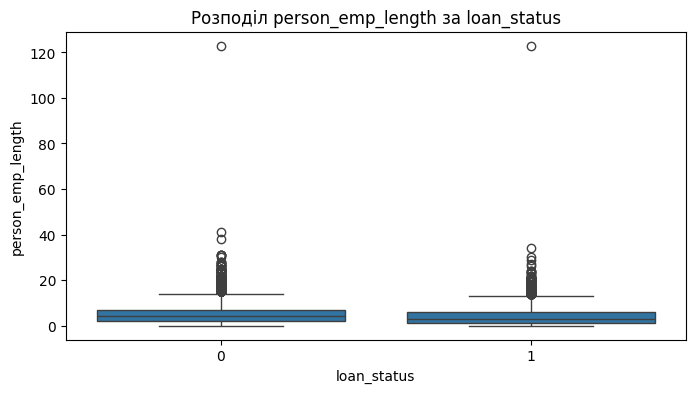

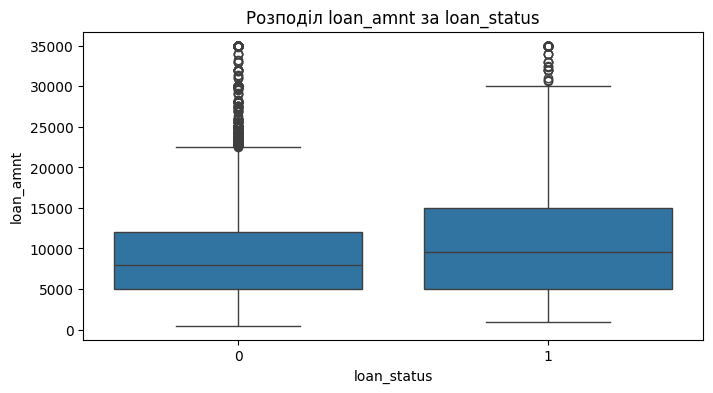

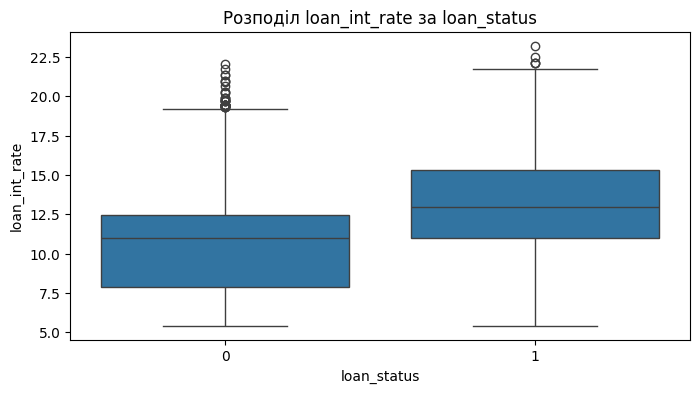

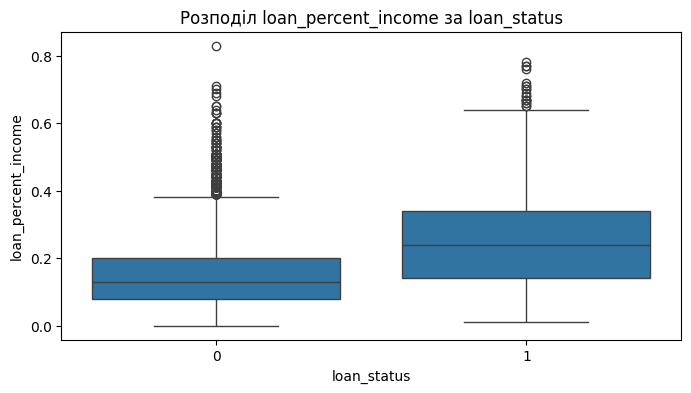

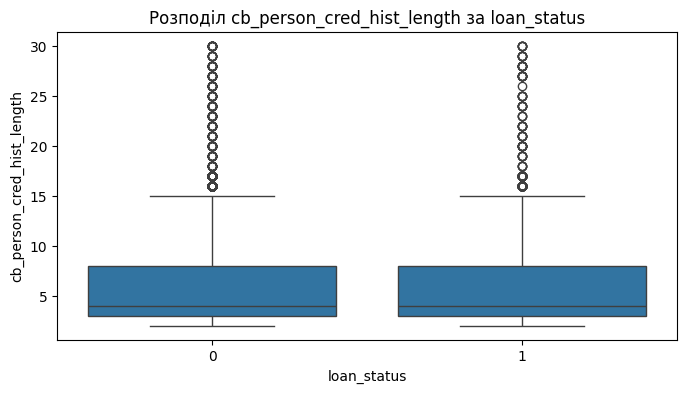

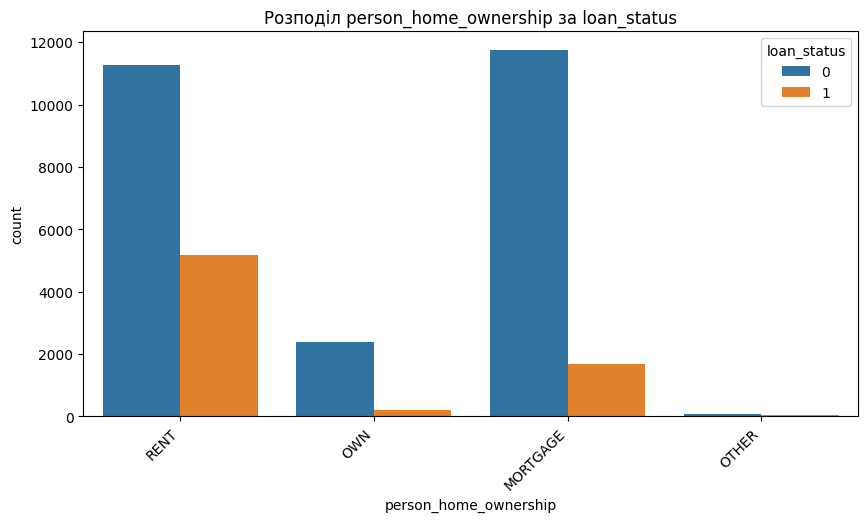

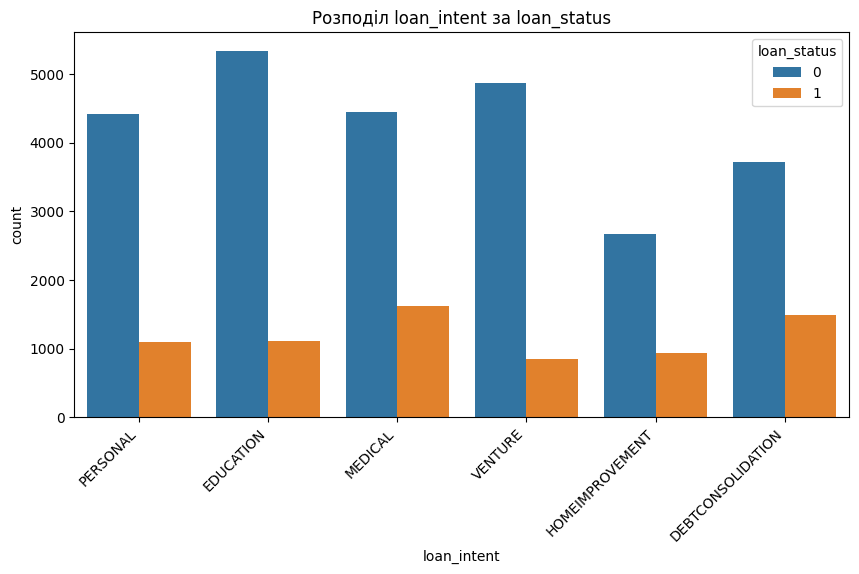

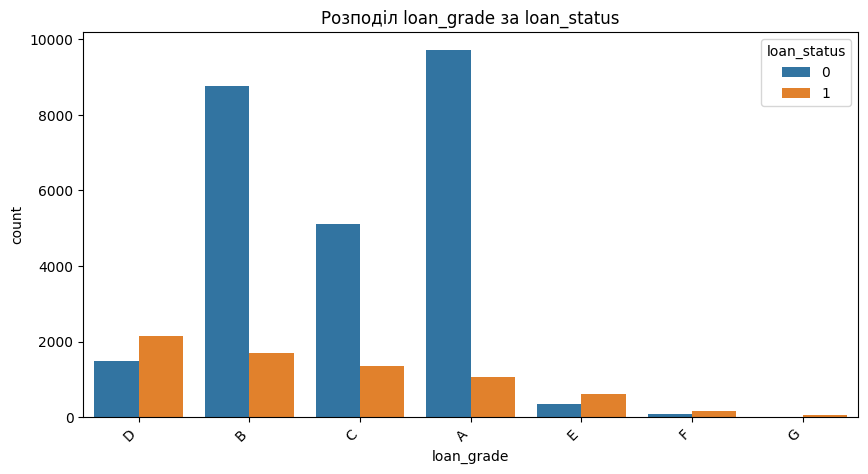

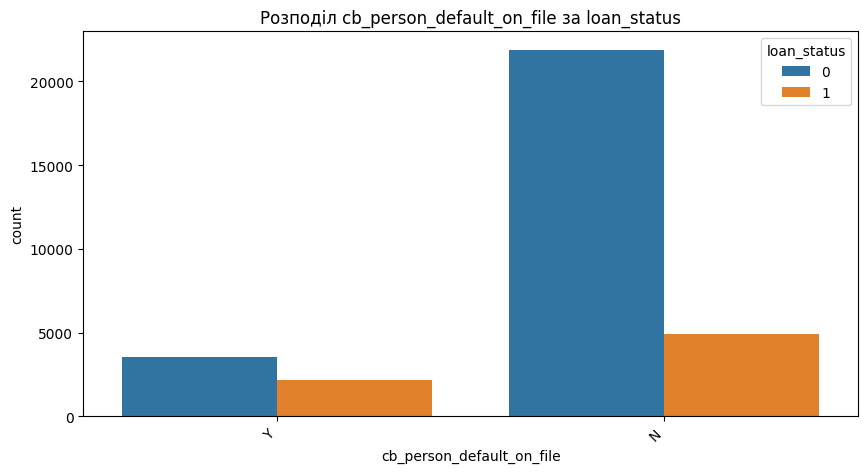

In [6]:
# 1. Обчислення відсотка пропущених значень
print("Відсоток пропущених значень:")
missing_values = df.isnull().sum() * 100 / len(df)
print(missing_values[missing_values > 0])

# Заповнення пропущених значень
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Заповнено пропущені значення в колонці '{col}' медіаною ({median_val}).")
        elif df[col].dtype == 'object':
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Заповнено пропущені значення в колонці '{col}' найбільш частим значенням ('{mode_val}').")

# Перевірка після заповнення
print("\nПеревірка на пропущені значення після заповнення:")
print(df.isnull().sum().sum())


# 2. Аналіз розподілу числових змінних
print("\nОпис числових змінних:")
display(df.describe())

# 3. Обробка викидів в person_income за допомогою IQR
print("\nОбробка викидів в person_income:")
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)].shape[0]
print(f"Кількість викидів у person_income: {outliers_count}")

# Видалення викидів (або можна замінити на медіану/середнє, залежно від задачі)
df_cleaned = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()
print(f"Розмір датасету після видалення викидів: {df_cleaned.shape}")


# 4. Аналіз категоріальних змінних відносно цільової та частота зустрічання
print("\nАналіз категоріальних змінних:")
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nРозподіл значень в колонці '{col}':")
    print(df[col].value_counts())
    print(f"\nРозподіл '{col}' відносно loan_status:")
    display(df.groupby([col, 'loan_status']).size().unstack(fill_value=0))

# 5. Візуалізація взаємозв'язку ознак з цільовою змінною
import matplotlib.pyplot as plt
import seaborn as sns

print("\nВізуалізація взаємозв'язків з loan_status:")

# Числові змінні
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('loan_status') # Видаляємо цільову змінну

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'Розподіл {col} за loan_status')
    plt.show()

# Категоріальні змінні
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.title(f'Розподіл {col} за loan_status')
    plt.xticks(rotation=45, ha='right')
    plt.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



Матриця кореляцій:


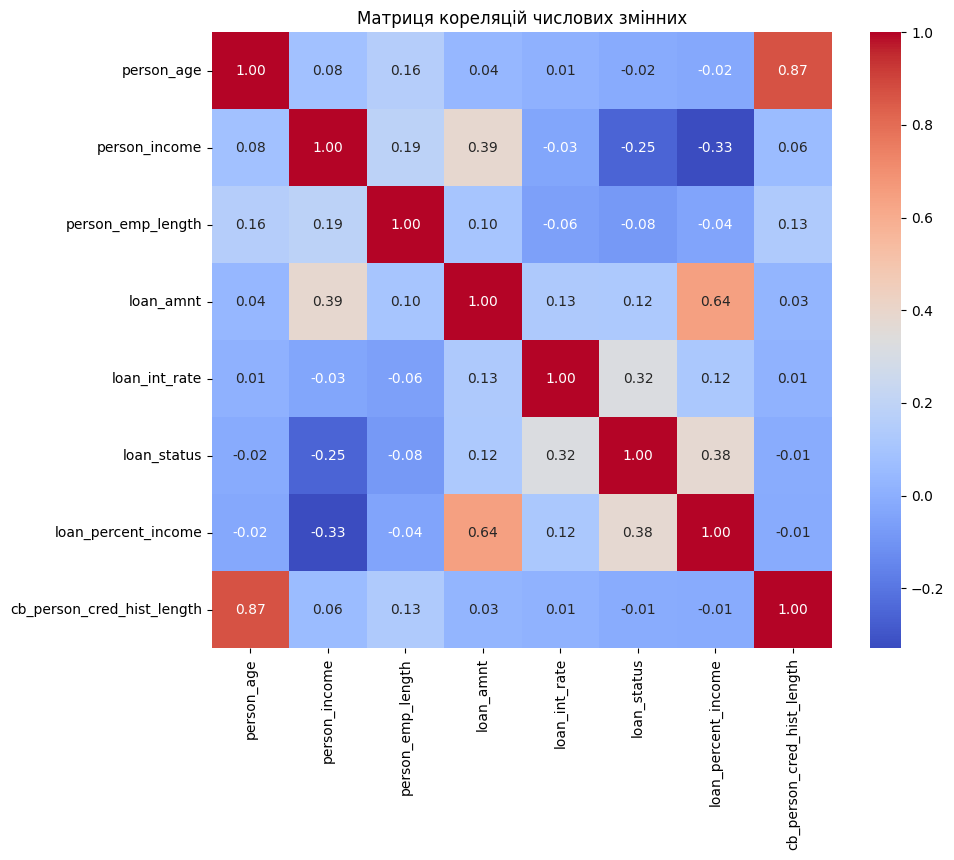


Кодування категоріальних змінних:
Перші 5 рядків після кодування:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True



Кількість ознак після кодування: 23


In [7]:
# 1. Побудова матриці кореляцій для числових змінних
print("Матриця кореляцій:")
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матриця кореляцій числових змінних')
plt.show()


# 2. Кодування категоріальних змінних
print("\nКодування категоріальних змінних:")
categorical_cols = df_cleaned.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("Перші 5 рядків після кодування:")
display(df_encoded.head())

# 3. Вибір фінального набору ознак
# Наразі лишаємо всі закодовані ознаки
print(f"\nКількість ознак після кодування: {df_encoded.shape[1]}")


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Розділення даних на X та y
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 2. Поділ на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Використовуємо stratify через незбалансованість класів

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")


# 3. Застосування масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nДані масштабовано.")


# 4. Навчання моделі логістичної регресії
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("\nМодель логістичної регресії навчена.")

# 5. Зробити прогнози на тренувальній та тестовій вибірках
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("\nПрогнози отримано.")

Розмір навчальної вибірки: (24877, 22)
Розмір тестової вибірки: (6220, 22)

Дані масштабовано.

Модель логістичної регресії навчена.

Прогнози отримано.



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


Confusion Matrix (Тестова вибірка):


,Predicted 0,Predicted 1
Actual 0,4596,231
Actual 1,601,792



Метрики оцінки моделі (Тестова вибірка):
Accuracy: 0.8662
Precision: 0.7742
Recall: 0.5686
F1-score: 0.6556

ROC-крива та AUC:


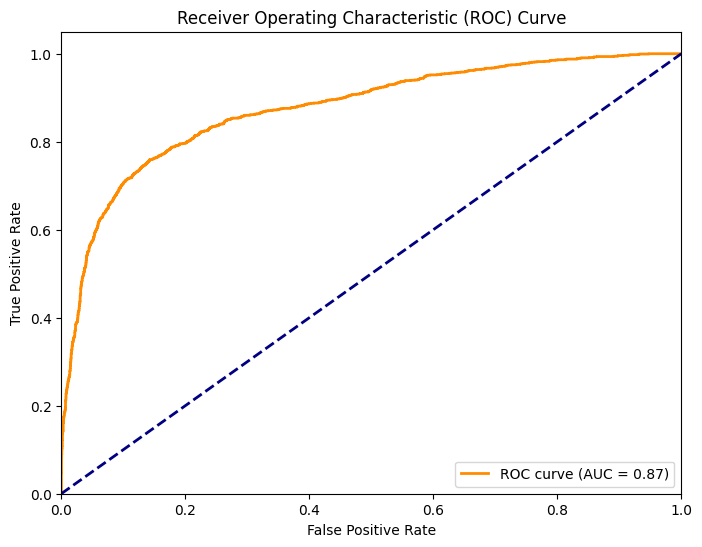


Важливість ознак (коефіцієнти моделі):


,feature,coefficient,abs_coefficient
5,loan_percent_income,1.318553,1.318553
17,loan_grade_D,0.812938,0.812938
3,loan_amnt,-0.546248,0.546248
18,loan_grade_E,0.477536,0.477536
8,person_home_ownership_OWN,-0.459162,0.459162
9,person_home_ownership_RENT,0.404043,0.404043
14,loan_intent_VENTURE,-0.400211,0.400211
10,loan_intent_EDUCATION,-0.326753,0.326753
20,loan_grade_G,0.309888,0.309888
19,loan_grade_F,0.269311,0.269311



Висновки:
Модель логістичної регресії має Accuracy: 0.8662, що показує загальну точність.
Precision: 0.7742 вказує на частку правильно спрогнозованих дефолтів серед усіх спрогнозованих дефолтів.
Recall: 0.5686 показує частку правильно спрогнозованих дефолтів серед усіх фактичних дефолтів.
F1-score: 0.6556 - це гармонійне середнє між Precision та Recall.
AUC: 0.87 вказує на загальну здатність моделі розрізняти позитивні та негативні класи.

Для логістичної регресії важливість ознак можна оцінити за абсолютним значенням коефіцієнтів моделі.
Ознаки з більшим абсолютним значенням коефіцієнта мають більший вплив на прогноз.


In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Побудова confusion matrix
print("Confusion Matrix (Тестова вибірка):")
cm = confusion_matrix(y_test, y_test_pred)
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


# 2. Обчислення основних метрик
print("\nМетрики оцінки моделі (Тестова вибірка):")
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# 3. Побудова ROC-кривої та обчислення AUC
print("\nROC-крива та AUC:")
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# 4. Проаналізуйте важливість ознак (для логістичної регресії можна використовувати коефіцієнти)
print("\nВажливість ознак (коефіцієнти моделі):")
coefficients = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
coefficients['abs_coefficient'] = abs(coefficients['coefficient'])
coefficients = coefficients.sort_values(by='abs_coefficient', ascending=False)
display(coefficients)

# 5. Висновки про якість моделі та які ознаки найбільше впливають на прогноз.
print("\nВисновки:")
print(f"Модель логістичної регресії має Accuracy: {accuracy:.4f}, що показує загальну точність.")
print(f"Precision: {precision:.4f} вказує на частку правильно спрогнозованих дефолтів серед усіх спрогнозованих дефолтів.")
print(f"Recall: {recall:.4f} показує частку правильно спрогнозованих дефолтів серед усіх фактичних дефолтів.")
print(f"F1-score: {f1:.4f} - це гармонійне середнє між Precision та Recall.")
print(f"AUC: {roc_auc:.2f} вказує на загальну здатність моделі розрізняти позитивні та негативні класи.")
print("\nДля логістичної регресії важливість ознак можна оцінити за абсолютним значенням коефіцієнтів моделі.")
print("Ознаки з більшим абсолютним значенням коефіцієнта мають більший вплив на прогноз.")


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



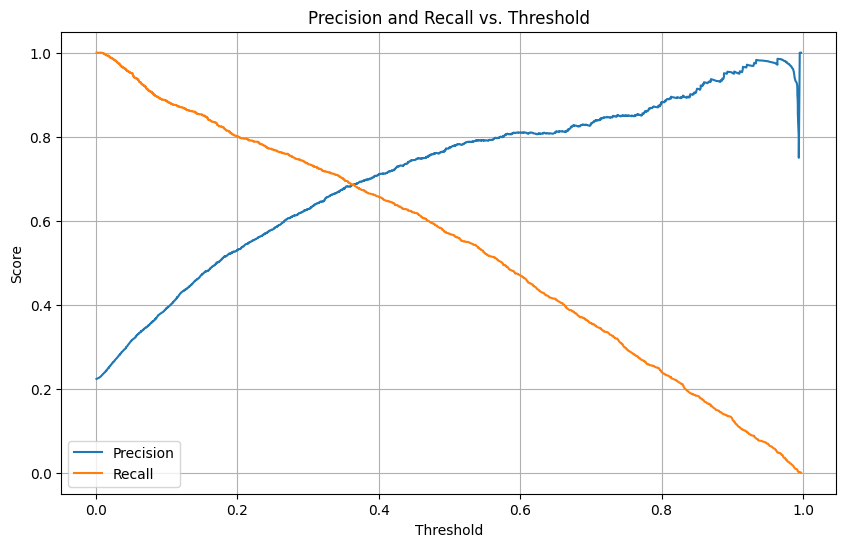

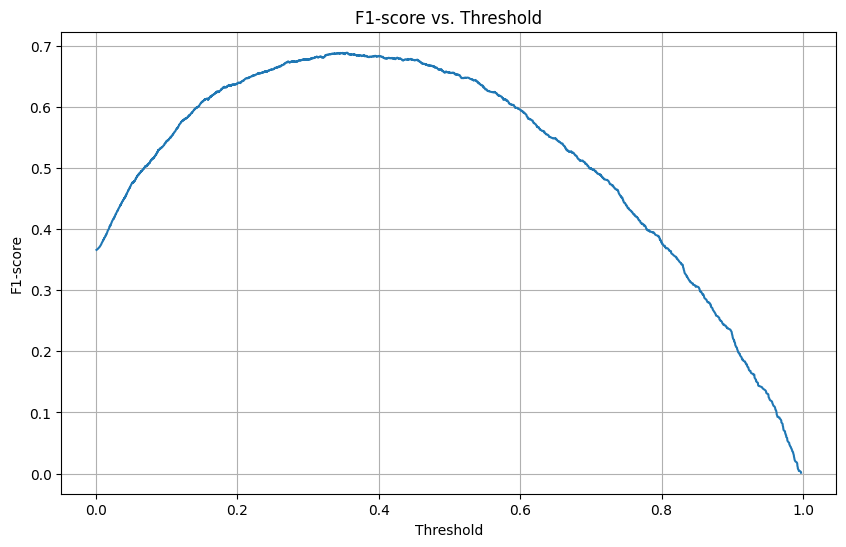


Метрики для різних порогів:
Threshold: 0.10, Precision: 0.3925, Recall: 0.8859, F1-score: 0.5440
Threshold: 0.30, Precision: 0.6278, Recall: 0.7351, F1-score: 0.6772
Threshold: 0.50, Precision: 0.7742, Recall: 0.5686, F1-score: 0.6556
Threshold: 0.70, Precision: 0.8311, Recall: 0.3568, F1-score: 0.4992
Threshold: 0.90, Precision: 0.9519, Recall: 0.1278, F1-score: 0.2253

Вибір оптимального порогу для бізнес-задачі:
Оптимальний поріг залежить від бізнес-мети.
Якщо важливо мінімізувати хибно-позитивні спрацювання (наприклад, не відмовити хорошому клієнту), варто обрати вищий поріг (вищий precision).
Якщо важливо виявити якомога більше дефолтів (мінімізувати хибно-негативні спрацювання), варто обрати нижчий поріг (вищий recall).
F1-score є гарним балансом між precision та recall.

Приклад: Поріг, що максимізує F1-score: 0.3550


In [13]:
from sklearn.metrics import precision_recall_curve

# 1. Аналіз метрик при різних порогах класифікації
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

# Візуалізація зміни метрик при зміні порогу
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Обчислення F1-score для різних порогів
f1_scores = 2 * (precision * recall) / (precision + recall)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold')
plt.grid(True)
plt.show()


# Проаналізуйте метрики при мінімум 5 різних порогах
print("\nМетрики для різних порогів:")
thresholds_to_check = [0.1, 0.3, 0.5, 0.7, 0.9]

for threshold in thresholds_to_check:
    y_test_pred_threshold = (y_test_prob >= threshold).astype(int)
    precision_t = precision_score(y_test, y_test_pred_threshold)
    recall_t = recall_score(y_test, y_test_pred_threshold)
    f1_t = f1_score(y_test, y_test_pred_threshold)
    print(f"Threshold: {threshold:.2f}, Precision: {precision_t:.4f}, Recall: {recall_t:.4f}, F1-score: {f1_t:.4f}")

# 2. Оберіть оптимальний поріг для бізнес-задачі
print("\nВибір оптимального порогу для бізнес-задачі:")
print("Оптимальний поріг залежить від бізнес-мети.")
print("Якщо важливо мінімізувати хибно-позитивні спрацювання (наприклад, не відмовити хорошому клієнту), варто обрати вищий поріг (вищий precision).")
print("Якщо важливо виявити якомога більше дефолтів (мінімізувати хибно-негативні спрацювання), варто обрати нижчий поріг (вищий recall).")
print("F1-score є гарним балансом між precision та recall.")
# Приклад вибору порогу, що максимізує F1-score
optimal_threshold_f1 = thresholds[np.argmax(f1_scores)]
print(f"\nПриклад: Поріг, що максимізує F1-score: {optimal_threshold_f1:.4f}")

# Можна також візуально обрати поріг з графіків, дивлячись на баланс між Precision та Recall, що відповідає бізнес-вимогам.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Навчання Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Прогнози на тестовій вибірці для Decision Tree
y_test_pred_dt = dt_model.predict(X_test_scaled)

# Оцінка Decision Tree
accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
precision_dt = precision_score(y_test, y_test_pred_dt)
recall_dt = recall_score(y_test, y_test_pred_dt)
f1_dt = f1_score(y_test, y_test_pred_dt)

print("Оцінка Decision Tree Classifier (Тестова вибірка):")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")


print("-" * 30)

# Навчання RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Прогнози на тестовій вибірці для Random Forest
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Оцінка Random Forest
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)

print("Оцінка RandomForestClassifier (Тестова вибірка):")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("-" * 30)

# Порівняння з логістичною регресією (результати з Завдання 5)
print("Порівняння з Logistic Regression (Тестова вибірка):")
# Print string representation directly
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


print("\nВисновки:")
print("Порівнюючи метрики Accuracy, Precision, Recall та F1-score, можна визначити, яка модель краще справляється з задачею прогнозування кредитного ризику на тестовій вибірці.")
print("Оптимальний вибір моделі залежить від того, яка метрика є найважливішою для конкретної бізнес-задачі (наприклад, високий Recall для мінімізації хибно-негативних спрацювань).")

Оцінка Decision Tree Classifier (Тестова вибірка):
Accuracy: 0.8916
Precision: 0.7544
Recall: 0.7653
F1-score: 0.7598
------------------------------
Оцінка RandomForestClassifier (Тестова вибірка):
Accuracy: 0.9291
Precision: 0.9595
Recall: 0.7136
F1-score: 0.8184
------------------------------
Порівняння з Logistic Regression (Тестова вибірка):
Accuracy: 0.8662379421221865
Precision: [0.22395498 0.223991   0.22402702 ... 1.         1.         1.        ]
Recall: [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.43575018e-03
 7.17875090e-04 0.00000000e+00]
F1-score: 0.6556291390728477

Висновки:
Порівнюючи метрики Accuracy, Precision, Recall та F1-score, можна визначити, яка модель краще справляється з задачею прогнозування кредитного ризику на тестовій вибірці.
Оптимальний вибір моделі залежить від того, яка метрика є найважливішою для конкретної бізнес-задачі (наприклад, високий Recall для мінімізації хибно-негативних спрацювань).
